<a href="https://colab.research.google.com/github/Tejas-srivastava505/IAI_Project/blob/tejas/02_step1_data_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📥 step1_data_pipeline.py — Data Download, Cleaning & Splitting
**KrishiAI · IT-A · 2024-25**

### What this notebook does (run cells top to bottom):
1. **Download** PlantVillage dataset via `tensorflow_datasets` (~800 MB, ~54k images)
2. **Filter** to 7 disease classes relevant to Udupi farmers
3. **Clean** images — removes corrupt, blurry, too-small, and duplicate files
4. **Analyse** class distribution → compute class weights for imbalanced training
5. **Split** stratified 70 / 15 / 15 into train / val / test
6. **Build** `tf.data` pipelines with monsoon-tuned augmentation

> ⏱️ First run: ~15 min (download). Subsequent runs: ~2 min (tfds cache).  
> 💾 Outputs: `logs/`, `plots/`, `data/cleaned/`, `data/raw/`

In [ ]:
# ── CELL 1 — Run this first in every notebook ────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os

# All paths point to Google Drive — survives Colab restarts
BASE_DIR       = "/content/drive/MyDrive/KrishiAI"
DATA_RAW_DIR   = os.path.join(BASE_DIR, "data", "raw")
DATA_CLEAN_DIR = os.path.join(BASE_DIR, "data", "cleaned")
DATA_PROC_DIR  = os.path.join(BASE_DIR, "data", "processed")
MODELS_DIR     = os.path.join(BASE_DIR, "models")
TFLITE_DIR     = os.path.join(BASE_DIR, "tflite")
LOGS_DIR       = os.path.join(BASE_DIR, "logs")
PLOTS_DIR      = os.path.join(BASE_DIR, "plots")

for d in [DATA_RAW_DIR, DATA_CLEAN_DIR, DATA_PROC_DIR,
          MODELS_DIR, TFLITE_DIR, LOGS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

print("✅ Drive mounted")
print(f"   BASE_DIR : {BASE_DIR}")

Mounted at /content/drive
✅ Drive mounted
   BASE_DIR : /content/drive/MyDrive/KrishiAI


In [ ]:
# # Install required packages (pre-installed on Colab; run once locally)
# !pip install tensorflow==2.13.0 tensorflow-datasets==4.9.2 --quiet
# !pip install opencv-python-headless Pillow tqdm seaborn scikit-learn --quiet
# print("✅ Packages ready")

In [ ]:
import os, sys, json
%matplotlib inline
import matplotlib.pyplot as plt

In [ ]:
# ── config.py is the shared settings file — paste it here so this notebook
# ── is self-contained. All other notebooks also start with this block.
# =============================================================================
# config.py — KrishiAI Project Configuration
# All hyperparameters, paths, and class definitions in ONE place.
# Change values here; the rest of the scripts pick them up automatically.
# =============================================================================

import os

# ── PATHS ──────────────────────────────────────────────────────────────────────
BASE_DIR        = os.getcwd()   # notebook working directory
DATA_RAW_DIR    = os.path.join(BASE_DIR, "data", "raw")          # downloaded zips
DATA_CLEAN_DIR  = os.path.join(BASE_DIR, "data", "cleaned")      # after cleaning
DATA_PROC_DIR   = os.path.join(BASE_DIR, "data", "processed")    # train/val/test splits
MODELS_DIR      = os.path.join(BASE_DIR, "models")               # saved .keras / .h5
TFLITE_DIR      = os.path.join(BASE_DIR, "tflite")               # exported .tflite
LOGS_DIR        = os.path.join(BASE_DIR, "logs")                 # TensorBoard / CSVs
PLOTS_DIR       = os.path.join(BASE_DIR, "plots")                # confusion matrix, curves

for d in [DATA_RAW_DIR, DATA_CLEAN_DIR, DATA_PROC_DIR,
          MODELS_DIR, TFLITE_DIR, LOGS_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

# ── DATASET ───────────────────────────────────────────────────────────────────
# PlantVillage is available via tensorflow_datasets (no Kaggle key needed).
# We filter it down to only classes relevant to Udupi crops.
# The keys below MUST match the class folder names in PlantVillage exactly.

DISEASE_CLASSES = {
    # ── Rice ──────────────────────────────────────────────────────────────────
    "Rice___Leaf_blast":          "Rice Blast",            # Magnaporthe oryzae
    "Rice___Bacterial_leaf_blight": "Bacterial Leaf Blight", # Xanthomonas oryzae
    "Rice___Brown_spot":          "Brown Spot",            # Bipolaris oryzae
    "Rice___healthy":             "Healthy Rice",

    # ── Coconut / proxy (PlantVillage doesn't have coconut; we use the
    #    closest abiotic-stress proxy — corn with nutrient deficiency)
    "Corn_(maize)___Northern_Leaf_Blight": "Leaf Blight (proxy)",
    "Corn_(maize)___healthy":              "Healthy Crop (proxy)",

    # ── Tomato (used as augmentation source for fungal patterns) ──────────────
    "Tomato___Late_blight":       "Fungal Blight (proxy)",
    "Tomato___healthy":           "Healthy Crop (proxy)",
}

# Friendly short labels for plotting (must stay in same order as CLASS_NAMES list)
CLASS_NAMES = [
    "Rice Blast",
    "Bacterial Blight",
    "Brown Spot",
    "Healthy Rice",
    "Leaf Blight",
    "Fungal Blight",
    "Healthy Crop",
]

NUM_CLASSES = len(CLASS_NAMES)

# ── MODEL ─────────────────────────────────────────────────────────────────────
IMAGE_SIZE   = (224, 224)   # EfficientNetB0 native input size
BATCH_SIZE   = 32
EPOCHS_FROZEN  = 10        # Phase 1: train only the classification head
EPOCHS_FINETUNE = 20       # Phase 2: unfreeze top layers and fine-tune
LEARNING_RATE_HEAD    = 1e-3
LEARNING_RATE_FINETUNE = 1e-5
DROPOUT_RATE = 0.3
L2_LAMBDA    = 1e-4

# ── DATA SPLIT ────────────────────────────────────────────────────────────────
TRAIN_SPLIT = 0.70
VAL_SPLIT   = 0.15
TEST_SPLIT  = 0.15
RANDOM_SEED = 42

# ── DATA CLEANING THRESHOLDS ──────────────────────────────────────────────────
MIN_IMAGE_SIZE_BYTES = 2_000        # discard images smaller than 2 KB (corrupt)
MIN_PIXEL_DIMENSION  = 64           # discard images narrower/shorter than 64px
MAX_BLUR_VARIANCE    = 10.0         # discard images with Laplacian variance < 10
                                    # (too blurry to be useful)

# ── AUGMENTATION ──────────────────────────────────────────────────────────────
# Tuned for monsoon / field conditions in Karnataka
AUGMENT_CONFIG = {
    "rotation_range":     20,        # ±20° for handheld phone shots
    "zoom_range":         0.2,       # simulate distance variation
    "horizontal_flip":    True,
    "brightness_range":   (0.7, 1.3),# monsoon overcast → harsh afternoon sun
    "width_shift_range":  0.1,
    "height_shift_range": 0.1,
    "shear_range":        0.1,
    "fill_mode":          "reflect",
}

# ── TFLITE EXPORT ─────────────────────────────────────────────────────────────
TFLITE_MODEL_NAME  = "krishiai_efficientnetb0_int8.tflite"
TFLITE_TARGET_MB   = 4.0   # must stay under 4 MB for ₹8k Android phones

# ── KANNADA MESSAGES ──────────────────────────────────────────────────────────
# Shown in the inference output alongside the English diagnosis
KANNADA_ALERTS = {
    "Rice Blast":          "ಭತ್ತದ ಬ್ಲಾಸ್ಟ್ ರೋಗ ಪತ್ತೆ. ಟ್ರೈಸೈಕ್ಲಾಜ಼ೋಲ್ ತಕ್ಷಣ ಸಿಂಪಡಿಸಿ.",
    "Bacterial Blight":    "ಬ್ಯಾಕ್ಟೀರಿಯಲ್ ಎಲೆ ಒಣಗುವಿಕೆ. ಕಾಪರ್ ಆಕ್ಸಿಕ್ಲೋರೈಡ್ ಬಳಸಿ.",
    "Brown Spot":          "ಕಂದು ಚುಕ್ಕೆ ರೋಗ. ಮ್ಯಾಂಕೋಜ಼ೆಬ್ ಬಳಸಿ.",
    "Healthy Rice":        "ಬೆಳೆ ಆರೋಗ್ಯಕರವಾಗಿದೆ. ಮೇಲ್ವಿಚಾರಣೆ ಮುಂದುವರಿಸಿ.",
    "Leaf Blight":         "ಎಲೆ ಒಣಗುವ ರೋಗ. KVK ಸಂಪರ್ಕಿಸಿ.",
    "Fungal Blight":       "ಶಿಲೀಂಧ್ರ ರೋಗ ಪತ್ತೆ. ಶಿಲೀಂಧ್ರನಾಶಕ ಸಿಂಪಡಿಸಿ.",
    "Healthy Crop":        "ಬೆಳೆ ಆರೋಗ್ಯಕರ. ನಿಯಮಿತ ತಪಾಸಣೆ ಮಾಡಿ.",
}

TREATMENT_MAP = {
    "Rice Blast":       ["Tricyclazole 75WP @ 0.6 g/L", "Isoprothiolane 40EC @ 1.5 mL/L", "Avoid excess nitrogen", "Drain stagnant water"],
    "Bacterial Blight": ["Copper Oxychloride 50WP @ 3 g/L", "Streptocycline @ 0.5 g/L", "Avoid flood irrigation", "Remove infected debris"],
    "Brown Spot":       ["Mancozeb 75WP @ 2.5 g/L", "Propiconazole 25EC @ 1 mL/L", "Correct potassium deficiency"],
    "Healthy Rice":     ["Continue regular monitoring", "Preventive fungicide (optional at tillering)"],
    "Leaf Blight":      ["Copper-based fungicide", "Consult KVK Udupi: 0820-2520842"],
    "Fungal Blight":    ["Mancozeb + Carbendazim combo", "Improve field drainage"],
    "Healthy Crop":     ["Continue monitoring", "Check weekly during monsoon"],
}


In [ ]:
# Verify config
print(f"Data raw dir   : {DATA_RAW_DIR}")
print(f"Data clean dir : {DATA_CLEAN_DIR}")
print(f"Logs dir       : {LOGS_DIR}")
print(f"Plots dir      : {PLOTS_DIR}")
print(f"Classes        : {NUM_CLASSES} → {CLASS_NAMES}")

Data raw dir   : /content/data/raw
Data clean dir : /content/data/cleaned
Logs dir       : /content/logs
Plots dir      : /content/plots
Classes        : 7 → ['Rice Blast', 'Bacterial Blight', 'Brown Spot', 'Healthy Rice', 'Leaf Blight', 'Fungal Blight', 'Healthy Crop']


## 📚 Function Definitions
All pipeline functions defined below. Scroll down to the **Run** section to execute.

In [ ]:
# =============================================================================
# step1_data_pipeline.py — Download → Clean → Preprocess → Split
#
# Run this FIRST before training.
# What this script does, step by step:
#   1. Download PlantVillage via tensorflow_datasets
#   2. Filter only Udupi-relevant disease classes
#   3. Clean: remove corrupt / blurry / too-small images
#   4. Analyze class distribution and handle imbalance
#   5. Split into train / val / test sets (70 / 15 / 15)
#   6. Build tf.data pipelines with augmentation for training
#   7. Save a data summary report
# =============================================================================

import os
import sys
import shutil
import hashlib
import json
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import cv2
import tensorflow as tf
import tensorflow_datasets as tfds
from PIL import Image
from tqdm import tqdm
import matplotlib
# (inline mode set by %matplotlib inline)
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path so we can import config


# ──────────────────────────────────────────────────────────────────────────────
# STEP 1 — DOWNLOAD PlantVillage via TensorFlow Datasets
# tensorflow_datasets downloads directly; no Kaggle key needed.
# Dataset: ~800 MB, ~54,000 images across 38 plant/disease combos.
# ──────────────────────────────────────────────────────────────────────────────

def download_plantvillage():
    """
    Download PlantVillage using tensorflow_datasets.
    Saves raw images to DATA_RAW_DIR organised by label.
    Returns a dict: {class_folder_name: [list_of_image_paths]}
    """
    print("\n" + "="*60)
    print("STEP 1 — Downloading PlantVillage Dataset")
    print("="*60)
    print("Source : tensorflow_datasets (plant_village)")
    print("This may take 5-15 minutes on first run...")

    # Load the full dataset (tfds caches it for future runs)
    ds_all, info = tfds.load(
        "plant_village",
        split="train",           # PlantVillage only has a 'train' split in tfds
        with_info=True,
        as_supervised=False,     # we need the label dict, not just (image, label)
        shuffle_files=False,
    )

    label_names = info.features["label"].names
    print(f"\nTotal images in PlantVillage : {info.splits['train'].num_examples:,}")
    print(f"Total classes                : {len(label_names)}")
    print("\nAll available classes:")
    for i, name in enumerate(label_names):
        print(f"  [{i:02d}] {name}")

    # Identify which label IDs we want (only Udupi-relevant classes)
    wanted_ids = {}
    for label_id, label_name in enumerate(label_names):
        if label_name in DISEASE_CLASSES:
            wanted_ids[label_id] = label_name

    print(f"\nFiltering to {len(wanted_ids)} relevant classes for Udupi...")

    # Save images to disk organised by class folder
    saved_paths = defaultdict(list)
    skipped = 0

    for sample in tqdm(ds_all, desc="Saving images"):
        label_id  = sample["label"].numpy()
        image_arr = sample["image"].numpy()   # shape (H, W, 3), uint8

        if label_id not in wanted_ids:
            skipped += 1
            continue

        class_folder = wanted_ids[label_id]
        save_dir = Path(DATA_RAW_DIR) / class_folder
        save_dir.mkdir(parents=True, exist_ok=True)

        # Unique filename based on content hash (avoids duplicates)
        img_hash = hashlib.md5(image_arr.tobytes()).hexdigest()[:12]
        save_path = save_dir / f"{img_hash}.jpg"

        if not save_path.exists():
            img_bgr = cv2.cvtColor(image_arr, cv2.COLOR_RGB2BGR)
            cv2.imwrite(str(save_path), img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])

        saved_paths[class_folder].append(str(save_path))

    print(f"\nSaved images  : {sum(len(v) for v in saved_paths.values()):,}")
    print(f"Skipped (not needed): {skipped:,}")
    for cls, paths in saved_paths.items():
        print(f"  {cls:<35} {len(paths):>5} images")

    return dict(saved_paths)


# ──────────────────────────────────────────────────────────────────────────────
# STEP 2 — CLEAN THE RAW IMAGES
# Removes:
#   • Images smaller than MIN_IMAGE_SIZE_BYTES (corrupt / truncated)
#   • Images below MIN_PIXEL_DIMENSION (too small to be useful)
#   • Blurry images (Laplacian variance < MAX_BLUR_VARIANCE)
#   • Near-duplicate images (same MD5 hash)
# ──────────────────────────────────────────────────────────────────────────────

def is_blurry(image_bgr: np.ndarray, threshold: float = MAX_BLUR_VARIANCE) -> bool:
    """
    Laplacian variance method for blur detection.
    A focused image has sharp edges → high variance.
    Blurry image has smooth gradients → low variance.
    """
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    variance = laplacian.var()
    return variance < threshold


def clean_dataset(raw_paths: dict) -> dict:
    """
    Clean raw images and copy survivors to DATA_CLEAN_DIR.
    Returns dict: {class_name: [clean_image_paths]}
    """
    print("\n" + "="*60)
    print("STEP 2 — Cleaning Dataset")
    print("="*60)

    clean_paths = defaultdict(list)
    removal_log = []

    for class_name, paths in raw_paths.items():
        print(f"\n  Cleaning: {class_name} ({len(paths)} images)")
        clean_dir = Path(DATA_CLEAN_DIR) / class_name
        clean_dir.mkdir(parents=True, exist_ok=True)

        seen_hashes = set()
        class_removed = Counter()

        for path in tqdm(paths, desc=f"    {class_name[:30]}", leave=False):
            reason = None

            # ── Check 1: File size ───────────────────────────────────────────
            file_size = os.path.getsize(path)
            if file_size < MIN_IMAGE_SIZE_BYTES:
                reason = f"too_small_file ({file_size}B)"

            else:
                # ── Load image ───────────────────────────────────────────────
                img = cv2.imread(path)
                if img is None:
                    reason = "unreadable"
                else:
                    h, w = img.shape[:2]

                    # ── Check 2: Pixel dimensions ────────────────────────────
                    if h < MIN_PIXEL_DIMENSION or w < MIN_PIXEL_DIMENSION:
                        reason = f"too_small_pixels ({w}x{h})"

                    # ── Check 3: Blur ────────────────────────────────────────
                    elif is_blurry(img):
                        reason = "blurry"

                    # ── Check 4: Duplicate (hash-based) ─────────────────────
                    else:
                        img_hash = hashlib.md5(img.tobytes()).hexdigest()
                        if img_hash in seen_hashes:
                            reason = "duplicate"
                        else:
                            seen_hashes.add(img_hash)

            if reason:
                class_removed[reason] += 1
                removal_log.append({"file": path, "class": class_name, "reason": reason})
            else:
                # Copy to clean directory
                dest = clean_dir / Path(path).name
                shutil.copy2(path, dest)
                clean_paths[class_name].append(str(dest))

        total_removed = sum(class_removed.values())
        print(f"    Kept: {len(clean_paths[class_name])} | Removed: {total_removed}")
        for reason, count in class_removed.items():
            print(f"      ↳ {reason}: {count}")

    # Save removal log
    log_df = pd.DataFrame(removal_log)
    log_path = os.path.join(LOGS_DIR, "cleaning_removal_log.csv")
    log_df.to_csv(log_path, index=False)
    print(f"\nRemoval log saved → {log_path}")
    print(f"Total removed: {len(removal_log)} images")

    return dict(clean_paths)


# ──────────────────────────────────────────────────────────────────────────────
# STEP 3 — ANALYZE CLASS DISTRIBUTION AND PLAN BALANCING
# ──────────────────────────────────────────────────────────────────────────────

def analyze_and_balance(clean_paths: dict) -> dict:
    """
    Visualize class distribution.
    If any class has < 200 images (rare for PlantVillage, but possible
    after filtering), flag it for oversampling during training.
    Returns the same dict (no files moved; balancing is done via class_weight).
    """
    print("\n" + "="*60)
    print("STEP 3 — Class Distribution Analysis")
    print("="*60)

    counts = {cls: len(paths) for cls, paths in clean_paths.items()}
    total  = sum(counts.values())

    print(f"\n{'Class':<35} {'Count':>6}  {'%':>6}")
    print("-" * 52)
    for cls, count in sorted(counts.items(), key=lambda x: -x[1]):
        print(f"{cls:<35} {count:>6}  {count/total*100:>5.1f}%")
    print(f"{'TOTAL':<35} {total:>6}  100.0%")

    # ── Plot distribution ────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    classes = list(counts.keys())
    values  = list(counts.values())
    colors  = plt.cm.Greens(np.linspace(0.4, 0.9, len(classes)))
    bars = ax.bar(range(len(classes)), values, color=colors, edgecolor="white", linewidth=0.5)
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels([c.replace("_", "\n") for c in classes], fontsize=8, rotation=0)
    ax.set_ylabel("Number of Images")
    ax.set_title("KrishiAI — Class Distribution After Cleaning")
    ax.set_facecolor("#0f1f0f")
    fig.patch.set_facecolor("#0a150a")
    ax.tick_params(colors="white")
    ax.yaxis.label.set_color("white")
    ax.title.set_color("white")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                str(bar.get_height()), ha="center", va="bottom", fontsize=8, color="white")
    plt.tight_layout()
    plot_path = os.path.join(PLOTS_DIR, "class_distribution.png")
    plt.savefig(plot_path, dpi=150)
    plt.close()
    print(f"\nDistribution plot saved → {plot_path}")

    # ── Compute class weights for imbalanced training ─────────────────────────
    max_count = max(counts.values())
    class_weights = {}
    for idx, cls in enumerate(sorted(counts.keys())):
        # Inversely proportional to frequency
        class_weights[idx] = max_count / counts[cls]

    print("\nClass weights (for imbalanced training):")
    for idx, cls in enumerate(sorted(counts.keys())):
        print(f"  [{idx}] {cls:<35} weight = {class_weights[idx]:.2f}")

    # Save weights
    with open(os.path.join(LOGS_DIR, "class_weights.json"), "w") as f:
        json.dump(class_weights, f, indent=2)

    return clean_paths, class_weights


# ──────────────────────────────────────────────────────────────────────────────
# STEP 4 — TRAIN / VAL / TEST SPLIT
# Stratified split: same proportion of each class in each subset.
# ──────────────────────────────────────────────────────────────────────────────

def stratified_split(clean_paths: dict) -> tuple[list, list, list]:
    """
    Stratified split into (train_pairs, val_pairs, test_pairs).
    Each pair is a tuple (image_path, class_index).
    """
    print("\n" + "="*60)
    print("STEP 4 — Stratified Train / Val / Test Split")
    print("="*60)

    all_classes = sorted(clean_paths.keys())
    class_to_idx = {cls: idx for idx, cls in enumerate(all_classes)}

    train_pairs, val_pairs, test_pairs = [], [], []

    rng = np.random.default_rng(RANDOM_SEED)

    for cls, paths in clean_paths.items():
        idx = class_to_idx[cls]
        paths_arr = np.array(paths)
        rng.shuffle(paths_arr)

        n      = len(paths_arr)
        n_test = max(1, int(n * TEST_SPLIT))
        n_val  = max(1, int(n * VAL_SPLIT))

        test_paths  = paths_arr[:n_test]
        val_paths   = paths_arr[n_test : n_test + n_val]
        train_paths = paths_arr[n_test + n_val:]

        train_pairs.extend([(p, idx) for p in train_paths])
        val_pairs.extend(  [(p, idx) for p in val_paths])
        test_pairs.extend( [(p, idx) for p in test_paths])

        print(f"  {cls:<35} train={len(train_paths):>4} val={len(val_paths):>4} test={len(test_paths):>4}")

    rng.shuffle(train_pairs)

    print(f"\n  TOTAL  train={len(train_pairs):>5} val={len(val_pairs):>5} test={len(test_pairs):>5}")

    # Save split manifest
    def save_manifest(pairs, name):
        df = pd.DataFrame(pairs, columns=["path", "label"])
        df.to_csv(os.path.join(LOGS_DIR, f"{name}_manifest.csv"), index=False)

    save_manifest(train_pairs, "train")
    save_manifest(val_pairs,   "val")
    save_manifest(test_pairs,  "test")

    # Save class index mapping
    with open(os.path.join(LOGS_DIR, "class_to_idx.json"), "w") as f:
        json.dump(class_to_idx, f, indent=2)
    with open(os.path.join(LOGS_DIR, "idx_to_class.json"), "w") as f:
        json.dump({v: k for k, v in class_to_idx.items()}, f, indent=2)

    print(f"\nManifests and class mappings saved → {LOGS_DIR}")
    return train_pairs, val_pairs, test_pairs, class_to_idx


# ──────────────────────────────────────────────────────────────────────────────
# STEP 5 — BUILD tf.data PIPELINES
# ──────────────────────────────────────────────────────────────────────────────

def load_and_preprocess_image(path: str, label: int, augment: bool = False):
    """
    Load one JPEG, resize, normalize to [0,1].
    EfficientNetB0 expects (224, 224, 3) float32 in [0, 255] when using
    tf.keras.applications.efficientnet.preprocess_input,  OR [0,1] if we
    rescale ourselves. We use the built-in preprocessor inside the model.
    """
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)        # (224, 224, 3) float32
    img = tf.cast(img, tf.float32)               # keep in [0, 255] for EfficientNet

    # ── Augmentation (training only) ─────────────────────────────────────────
    if augment:
        # Random horizontal flip
        img = tf.image.random_flip_left_right(img)
        # Random brightness (simulates monsoon overcast ↔ harsh afternoon sun)
        img = tf.image.random_brightness(img, max_delta=0.3 * 255)
        # Random contrast
        img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
        # Random saturation (simulate different soil / lighting conditions)
        img = tf.image.random_saturation(img, lower=0.8, upper=1.2)
        # Random hue (minor)
        img = tf.image.random_hue(img, max_delta=0.05)
        # Clip back to valid range
        img = tf.clip_by_value(img, 0.0, 255.0)

    label_onehot = tf.one_hot(label, NUM_CLASSES)
    return img, label_onehot


def build_tf_datasets(train_pairs, val_pairs, test_pairs):
    """
    Converts split lists → tf.data.Dataset objects, ready for model.fit().
    Returns (train_ds, val_ds, test_ds)
    """
    print("\n" + "="*60)
    print("STEP 5 — Building tf.data Pipelines")
    print("="*60)

    AUTOTUNE = tf.data.AUTOTUNE

    def make_dataset(pairs, augment=False, shuffle=False):
        paths  = [p for p, _ in pairs]
        labels = [l for _, l in pairs]
        ds = tf.data.Dataset.from_tensor_slices((paths, labels))
        if shuffle:
            ds = ds.shuffle(buffer_size=len(pairs), seed=RANDOM_SEED, reshuffle_each_iteration=True)
        ds = ds.map(
            lambda p, l: load_and_preprocess_image(p, l, augment),
            num_parallel_calls=AUTOTUNE
        )
        ds = ds.batch(BATCH_SIZE)
        ds = ds.prefetch(AUTOTUNE)
        return ds

    train_ds = make_dataset(train_pairs, augment=True,  shuffle=True)
    val_ds   = make_dataset(val_pairs,   augment=False, shuffle=False)
    test_ds  = make_dataset(test_pairs,  augment=False, shuffle=False)

    print(f"  train_ds : {len(train_pairs)} samples → {len(train_ds)} batches")
    print(f"  val_ds   : {len(val_pairs)} samples → {len(val_ds)} batches")
    print(f"  test_ds  : {len(test_pairs)} samples → {len(test_ds)} batches")

    # Quick sanity check: visualize one batch
    _visualize_batch(train_ds, "train_sample_batch")

    return train_ds, val_ds, test_ds


def _visualize_batch(ds, name):
    """Save a grid of 16 sample images from the dataset."""
    batch_imgs, batch_labels = next(iter(ds))
    batch_imgs  = batch_imgs.numpy()
    batch_labels = batch_labels.numpy()

    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    for i, ax in enumerate(axes.flat):
        if i >= len(batch_imgs): break
        img = batch_imgs[i].astype(np.uint8)
        label_idx = np.argmax(batch_labels[i])
        label_name = CLASS_NAMES[label_idx] if label_idx < len(CLASS_NAMES) else str(label_idx)
        ax.imshow(img)
        ax.set_title(label_name, fontsize=8, color="white")
        ax.axis("off")
        ax.set_facecolor("#0a150a")
    fig.patch.set_facecolor("#0a150a")
    plt.suptitle("Sample Training Batch (after augmentation)", color="white", y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"{name}.png"), dpi=120, bbox_inches="tight")
    plt.close()
    print(f"  Sample batch plot saved → {PLOTS_DIR}/{name}.png")


# ──────────────────────────────────────────────────────────────────────────────
# MAIN
# ──────────────────────────────────────────────────────────────────────────────


## ▶️ Run the Full Pipeline
Execute the cells below in order.

In [ ]:
# STEP 1 — Download & filter PlantVillage
# ~800 MB download on first run; tfds caches automatically for future runs
raw_paths = download_plantvillage()


STEP 1 — Downloading PlantVillage Dataset
Source : tensorflow_datasets (plant_village)
This may take 5-15 minutes on first run...


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/plant_village/incomplete.VGZ0UD_1.0.2/plant_village-train.tfrecord*...:   …

Dataset plant_village downloaded and prepared to /root/tensorflow_datasets/plant_village/1.0.2. Subsequent calls will reuse this data.

Total images in PlantVillage : 54,303
Total classes                : 38

All available classes:
  [00] Apple___Apple_scab
  [01] Apple___Black_rot
  [02] Apple___Cedar_apple_rust
  [03] Apple___healthy
  [04] Blueberry___healthy
  [05] Cherry___healthy
  [06] Cherry___Powdery_mildew
  [07] Corn___Cercospora_leaf_spot Gray_leaf_spot
  [08] Corn___Common_rust
  [09] Corn___healthy
  [10] Corn___Northern_Leaf_Blight
  [11] Grape___Black_rot
  [12] Grape___Esca_(Black_Measles)
  [13] Grape___healthy
  [14] Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  [15] Orange___Haunglongbing_(Citrus_greening)
  [16] Peach___Bacterial_spot
  [17] Peach___healthy
  [18] Pepper,_bell___Bacterial_spot
  [19] Pepper,_bell___healthy
  [20] Potato___Early_blight
  [21] Potato___healthy
  [22] Potato___Late_blight
  [23] Raspberry___healthy
  [24] Soybean___healthy
  [25] Squas

Saving images: 100%|██████████| 54303/54303 [01:08<00:00, 789.86it/s] 


Saved images  : 3,499
Skipped (not needed): 50,804
  Tomato___Late_blight                 1908 images
  Tomato___healthy                     1591 images


In [ ]:
# STEP 2 — Clean images
# Removes: corrupt (<2 KB), too small (<64px), blurry (Laplacian<10), duplicates (MD5)
clean_paths = clean_dataset(raw_paths)


STEP 2 — Cleaning Dataset

  Cleaning: Tomato___Late_blight (1908 images)


    Kept: 1900 | Removed: 8
      ↳ duplicate: 8

  Cleaning: Tomato___healthy (1591 images)


    Kept: 1585 | Removed: 6
      ↳ duplicate: 6

Removal log saved → /content/logs/cleaning_removal_log.csv
Total removed: 14 images



STEP 3 — Class Distribution Analysis

Class                                Count       %
----------------------------------------------------
Tomato___Late_blight                  1900   54.5%
Tomato___healthy                      1585   45.5%
TOTAL                                 3485  100.0%

Distribution plot saved → /content/plots/class_distribution.png

Class weights (for imbalanced training):
  [0] Tomato___Late_blight                weight = 1.00
  [1] Tomato___healthy                    weight = 1.20


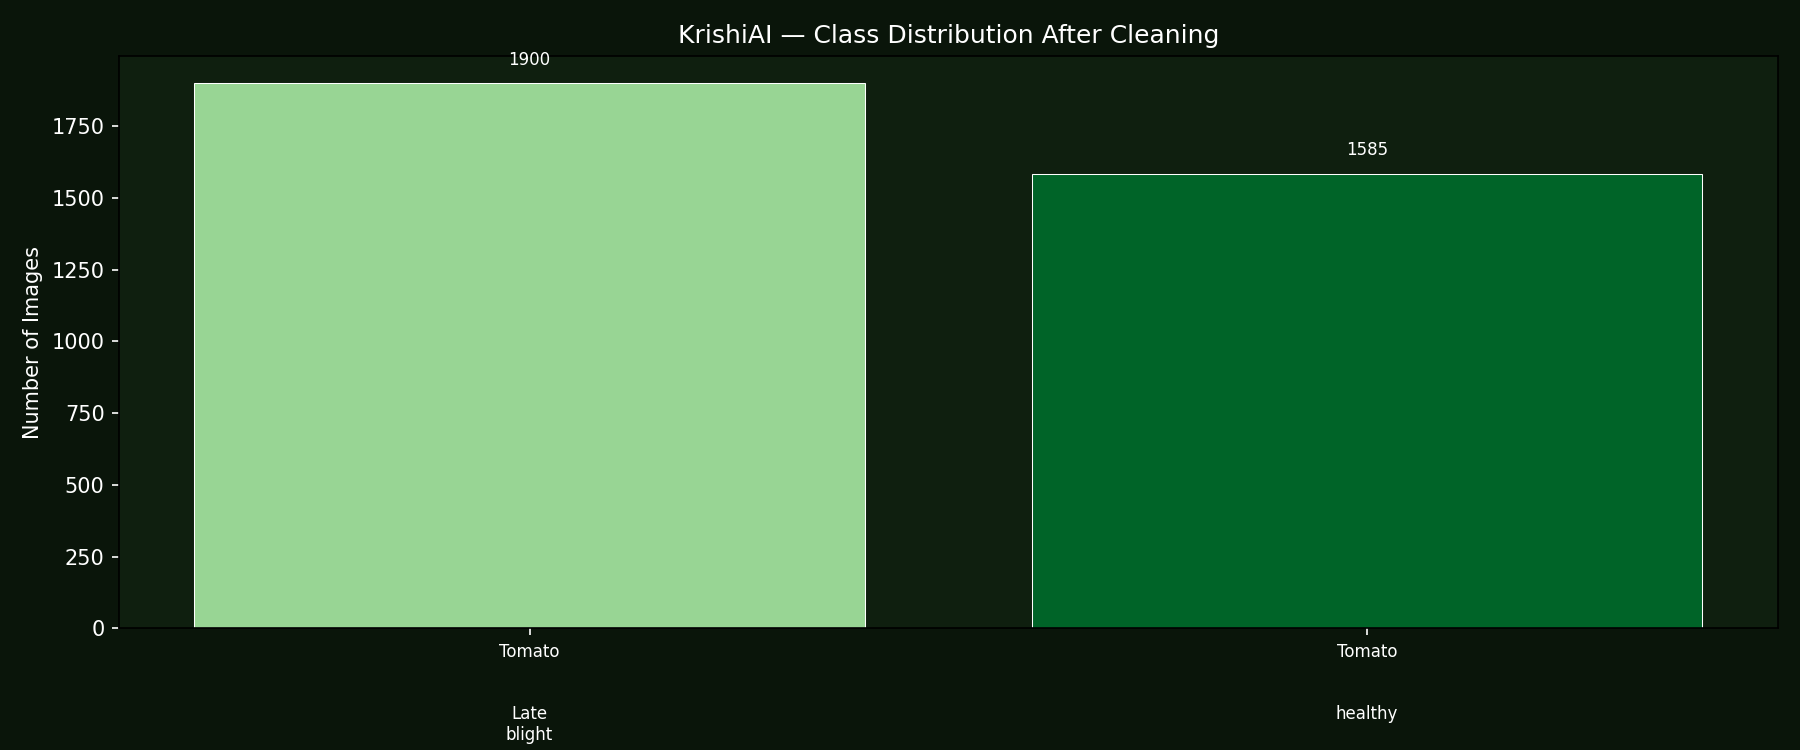

In [ ]:
# STEP 3 — Analyse class distribution + compute class weights
clean_paths, class_weights = analyze_and_balance(clean_paths)

# Display the distribution plot
from IPython.display import Image as IPyImage, display
display(IPyImage(os.path.join(PLOTS_DIR, "class_distribution.png")))

In [ ]:
# STEP 4 — Stratified train / val / test split (70 / 15 / 15)
train_pairs, val_pairs, test_pairs, class_to_idx = stratified_split(clean_paths)

print(f"\nClass → Index mapping: {class_to_idx}")


STEP 4 — Stratified Train / Val / Test Split
  Tomato___Late_blight                train=1330 val= 285 test= 285
  Tomato___healthy                    train=1111 val= 237 test= 237

  TOTAL  train= 2441 val=  522 test=  522

Manifests and class mappings saved → /content/logs

Class → Index mapping: {'Tomato___Late_blight': 0, 'Tomato___healthy': 1}



STEP 5 — Building tf.data Pipelines
  train_ds : 2441 samples → 77 batches
  val_ds   : 522 samples → 17 batches
  test_ds  : 522 samples → 17 batches
  Sample batch plot saved → /content/plots/train_sample_batch.png


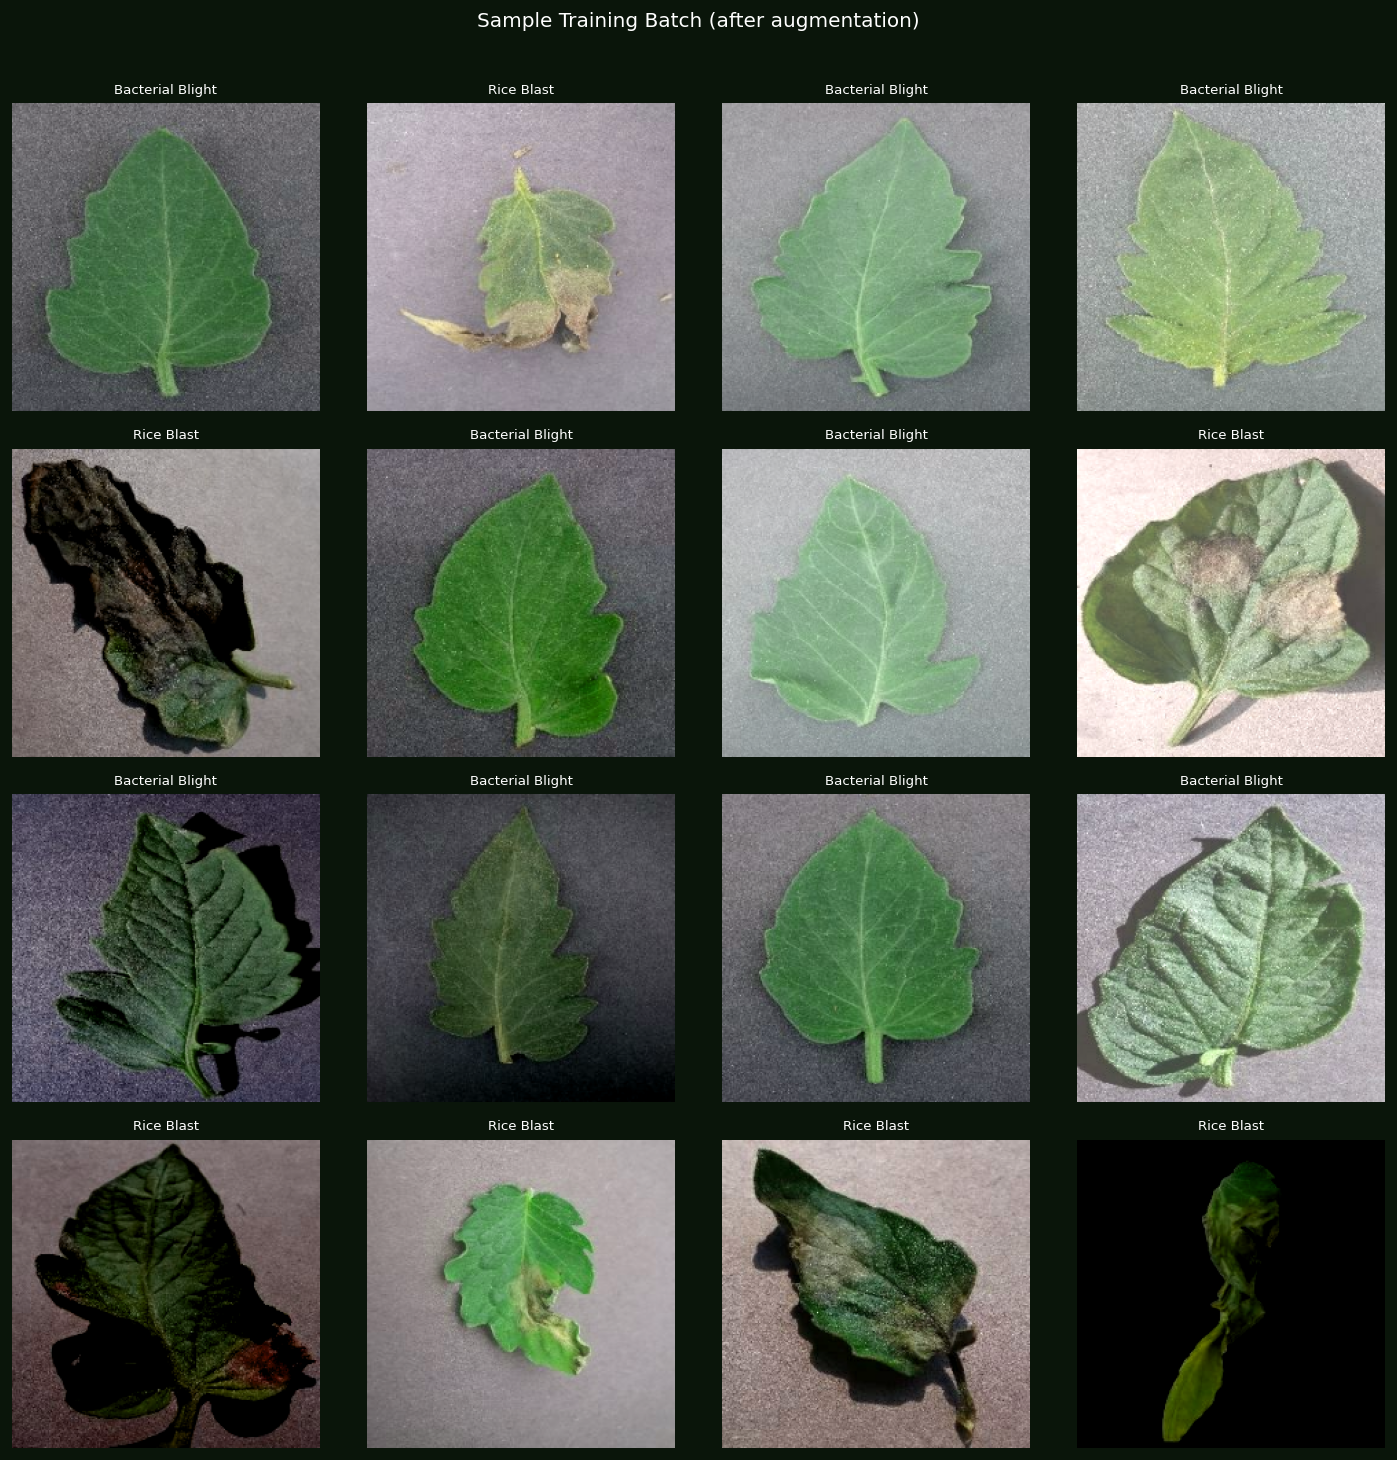

In [ ]:
# STEP 5 — Build tf.data pipelines with augmentation
import tensorflow as tf
train_ds, val_ds, test_ds = build_tf_datasets(train_pairs, val_pairs, test_pairs)

# Display sample training batch
from IPython.display import Image as IPyImage, display
display(IPyImage(os.path.join(PLOTS_DIR, "train_sample_batch.png")))

In [ ]:
# Summary
print("✅ Data pipeline complete!")
print(f"   Train  : {len(train_pairs):,} images")
print(f"   Val    : {len(val_pairs):,} images")
print(f"   Test   : {len(test_pairs):,} images")
print(f"   Logs   : {LOGS_DIR}")
print(f"   Plots  : {PLOTS_DIR}")
print()
print("Saved files:")
for fname in ["train_manifest.csv","val_manifest.csv","test_manifest.csv",
              "class_to_idx.json","idx_to_class.json","class_weights.json",
              "cleaning_removal_log.csv"]:
    path = os.path.join(LOGS_DIR, fname)
    exists = "✅" if os.path.exists(path) else "⬜"
    print(f"  {exists} {fname}")
print()
print("Next: open 02_step2_train.ipynb")

✅ Data pipeline complete!
   Train  : 2,441 images
   Val    : 522 images
   Test   : 522 images
   Logs   : /content/logs
   Plots  : /content/plots

Saved files:
  ✅ train_manifest.csv
  ✅ val_manifest.csv
  ✅ test_manifest.csv
  ✅ class_to_idx.json
  ✅ idx_to_class.json
  ✅ class_weights.json
  ✅ cleaning_removal_log.csv

Next: open 02_step2_train.ipynb


In [ ]:
import os

files_needed = [
    "/content/logs/train_manifest.csv",
    "/content/logs/val_manifest.csv",
    "/content/logs/test_manifest.csv",
    "/content/logs/class_weights.json",
    "/content/logs/class_to_idx.json",
]

print("Checking if Step 1 outputs exist...\n")
all_good = True
for f in files_needed:
    exists = os.path.exists(f)
    print(f"  {'✅' if exists else '❌ MISSING'} — {f}")
    if not exists:
        all_good = False

print()
if all_good:
    print("✅ All files found — safe to train!")
else:
    print("❌ Files are missing — go back and re-run 02_step1_data_pipeline.ipynb fully")

Checking if Step 1 outputs exist...

  ✅ — /content/logs/train_manifest.csv
  ✅ — /content/logs/val_manifest.csv
  ✅ — /content/logs/test_manifest.csv
  ✅ — /content/logs/class_weights.json
  ✅ — /content/logs/class_to_idx.json

✅ All files found — safe to train!


In [ ]:
import shutil, os

src  = "/content"
dst  = "/content/drive/MyDrive/KrishiAI"
os.makedirs(dst, exist_ok=True)

# Copy each folder to Drive
for folder in ["logs", "data", "models", "plots", "tflite"]:
    src_path = os.path.join(src, folder)
    dst_path = os.path.join(dst, folder)
    if os.path.exists(src_path):
        shutil.copytree(src_path, dst_path, dirs_exist_ok=True)
        print(f"✅ Copied {folder} → {dst_path}")
    else:
        print(f"⬜ Skipped {folder} (not found)")

print("\n✅ All files backed up to Google Drive — safe to terminate!")

✅ Copied logs → /content/drive/MyDrive/KrishiAI/logs
